In [6]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.processing import WESADDataset
from src.features import process_subject_data
from src.models import train_and_evaluate_loso

In [7]:
# S12 is excluded from WESAD due to data collection issues (documented in the paper)
ALL_SUBJECTS = [
    'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8',
    'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17'
]

loader = WESADDataset('../data/WESAD')

print(f"Subjects to process: {len(ALL_SUBJECTS)}")
print(ALL_SUBJECTS)

Subjects to process: 15
['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


In [8]:
all_features = []
failed = []

for subject in ALL_SUBJECTS:
    try:
        print(f"\n── {subject} ──────────────────────────────")
        df_raw  = loader.load_subject(subject)
        df      = loader.filter_target_states(df_raw)
        feat_df = process_subject_data(df)

        # Add Subject_ID column — required for LOSO grouping
        feat_df['Subject_ID'] = subject

        n_baseline = (feat_df['Label'] == 0).sum()
        n_stress   = (feat_df['Label'] == 1).sum()
        print(f"  Windows — Baseline: {n_baseline}, Stress: {n_stress}, Total: {len(feat_df)}")

        all_features.append(feat_df)

    except Exception as e:
        print(f"  ⚠️  Failed to process {subject}: {e}")
        failed.append(subject)

print(f"\n{'='*45}")
print(f"Processed: {len(all_features)} subjects")
if failed:
    print(f"Failed:    {failed}")


── S2 ──────────────────────────────
Loading S2 data... This might take a moment.
Extracting features using 60-second windows...
  Windows — Baseline: 19, Stress: 10, Total: 29

── S3 ──────────────────────────────
Loading S3 data... This might take a moment.
Extracting features using 60-second windows...
  Windows — Baseline: 19, Stress: 10, Total: 29

── S4 ──────────────────────────────
Loading S4 data... This might take a moment.
Extracting features using 60-second windows...
  Windows — Baseline: 19, Stress: 10, Total: 29

── S5 ──────────────────────────────
Loading S5 data... This might take a moment.
Extracting features using 60-second windows...
  Windows — Baseline: 20, Stress: 10, Total: 30

── S6 ──────────────────────────────
Loading S6 data... This might take a moment.
Extracting features using 60-second windows...
  Windows — Baseline: 20, Stress: 10, Total: 30

── S7 ──────────────────────────────
Loading S7 data... This might take a moment.
Extracting features using 6

In [9]:
full_df = pd.concat(all_features, ignore_index=True)

print(f"Total windows:   {len(full_df)}")
print(f"Total features:  {full_df.shape[1] - 2}")  # minus Label and Subject_ID
print(f"\nLabel distribution (all subjects):")
print(full_df['Label'].value_counts().sort_index().rename({0: 'Baseline', 1: 'Stress'}))
print(f"\nWindows per subject:")
print(full_df.groupby('Subject_ID').size().to_string())

Total windows:   451
Total features:  7

Label distribution (all subjects):
Label
Baseline    296
Stress      155
Name: count, dtype: int64

Windows per subject:
Subject_ID
S10    31
S11    31
S13    30
S14    30
S15    31
S16    30
S17    31
S2     29
S3     29
S4     29
S5     30
S6     30
S7     30
S8     30
S9     30


In [10]:
os.makedirs('../data', exist_ok=True)
full_df.to_csv('../data/features_all_subjects.csv', index=False)
print(f"Saved to ../data/features_all_subjects.csv")
print(f"Shape: {full_df.shape}")

Saved to ../data/features_all_subjects.csv
Shape: (451, 9)


In [11]:
results = train_and_evaluate_loso(full_df, save_dir='../models')

Preparing data for LOSO Cross-Validation...
Starting LOSO across 15 folds (one per subject)...

  Fold 01 | Subject S10 | Acc: 0.677 | F1: 0.286 | Windows: 31
  Fold 02 | Subject S11 | Acc: 0.806 | F1: 0.786 | Windows: 31
  Fold 03 | Subject S13 | Acc: 0.967 | F1: 0.952 | Windows: 30
  Fold 04 | Subject S14 | Acc: 0.833 | F1: 0.800 | Windows: 30
  Fold 05 | Subject S15 | Acc: 0.968 | F1: 0.952 | Windows: 31
  Fold 06 | Subject S16 | Acc: 1.000 | F1: 1.000 | Windows: 30
  Fold 07 | Subject S17 | Acc: 0.871 | F1: 0.833 | Windows: 31
  Fold 08 | Subject S2 | Acc: 0.621 | F1: 0.000 | Windows: 29
  Fold 09 | Subject S3 | Acc: 0.966 | F1: 0.947 | Windows: 29
  Fold 10 | Subject S4 | Acc: 0.690 | F1: 0.182 | Windows: 29
  Fold 11 | Subject S5 | Acc: 1.000 | F1: 1.000 | Windows: 30
  Fold 12 | Subject S6 | Acc: 0.933 | F1: 0.889 | Windows: 30
  Fold 13 | Subject S7 | Acc: 0.967 | F1: 0.947 | Windows: 30
  Fold 14 | Subject S8 | Acc: 0.967 | F1: 0.957 | Windows: 30
  Fold 15 | Subject S9 | Acc:

In [12]:
per_subject_df = pd.DataFrame(results['per_subject'])
per_subject_df = per_subject_df.sort_values('accuracy', ascending=False).reset_index(drop=True)

print("Per-Subject Results:")
print(per_subject_df.to_string(index=False))
print(f"\nBest subject:  {per_subject_df.iloc[0]['subject']}  "
      f"(Acc: {per_subject_df.iloc[0]['accuracy']:.3f})")
print(f"Worst subject: {per_subject_df.iloc[-1]['subject']}  "
      f"(Acc: {per_subject_df.iloc[-1]['accuracy']:.3f})")

Per-Subject Results:
subject  accuracy    f1  n_windows
    S16     1.000 1.000         30
     S5     1.000 1.000         30
    S15     0.968 0.952         31
     S7     0.967 0.947         30
     S8     0.967 0.957         30
    S13     0.967 0.952         30
     S3     0.966 0.947         29
     S6     0.933 0.889         30
     S9     0.900 0.842         30
    S17     0.871 0.833         31
    S14     0.833 0.800         30
    S11     0.806 0.786         31
     S4     0.690 0.182         29
    S10     0.677 0.286         31
     S2     0.621 0.000         29

Best subject:  S16  (Acc: 1.000)
Worst subject: S2  (Acc: 0.621)


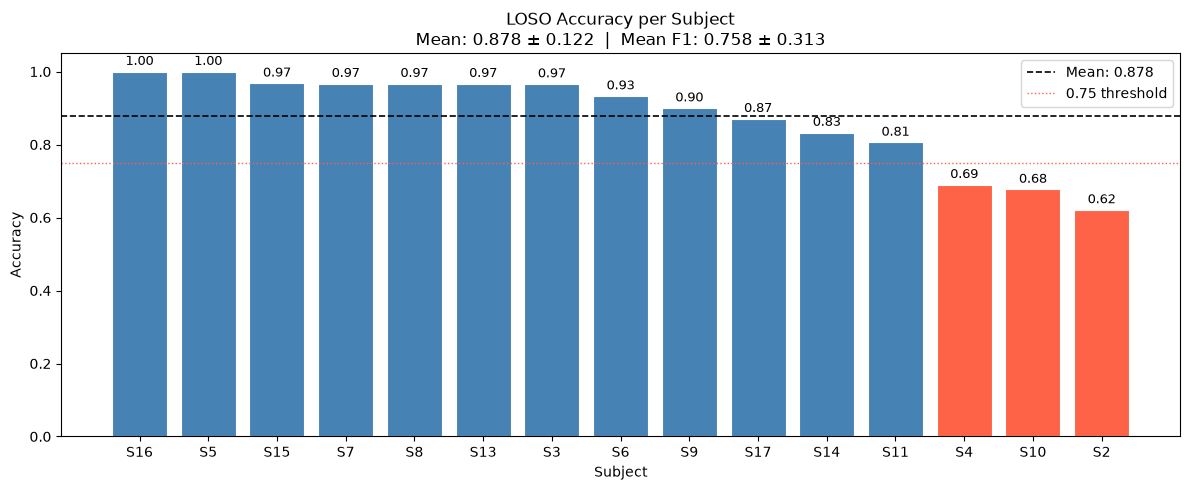

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['tomato' if acc < 0.75 else 'steelblue'
          for acc in per_subject_df['accuracy']]

bars = ax.bar(per_subject_df['subject'], per_subject_df['accuracy'],
              color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, per_subject_df['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(y=results['accuracy'], color='black', linestyle='--',
           linewidth=1.2, label=f"Mean: {results['accuracy']:.3f}")
ax.axhline(y=0.75, color='tomato', linestyle=':', linewidth=1,
           label='0.75 threshold')

ax.set_ylim(0, 1.05)
ax.set_xlabel('Subject')
ax.set_ylabel('Accuracy')
ax.set_title(f"LOSO Accuracy per Subject\n"
             f"Mean: {results['accuracy']:.3f} ± {results['accuracy_std']:.3f}  |  "
             f"Mean F1: {results['f1_score']:.3f} ± {results['f1_std']:.3f}",
             fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/loso_per_subject.png', dpi=150)
plt.show()

## LOSO Results — 15 Subjects

| Metric | Value |
|--------|-------|
| Mean Accuracy | 0.878 ± 0.122 |
| Mean F1 Score | 0.758 ± 0.313 |
| Subjects ≥ 0.90 accuracy | 9 / 15 |
| Subjects < 0.75 accuracy | 3 / 15 (S4, S10, S2) |

### Key Observations

**Strong generalization for most subjects:** 9/15 subjects achieve ≥0.90
accuracy, demonstrating the model learns meaningful cross-subject stress
patterns rather than subject-specific artifacts.

**S2 is the hardest subject (0.62):** This is notable because S2 was used
for the proof-of-concept in notebooks 01–05. The 0.933 accuracy in
notebook 04 reflected within-subject fitting, not generalization.
This underscores why LOSO evaluation is essential in biosignal research.

**High F1 standard deviation (0.313):** The model performs inconsistently
on the stress class across subjects. Future work could explore
subject-specific normalization or personalized adaptation layers to
improve minority-class recall for harder subjects.

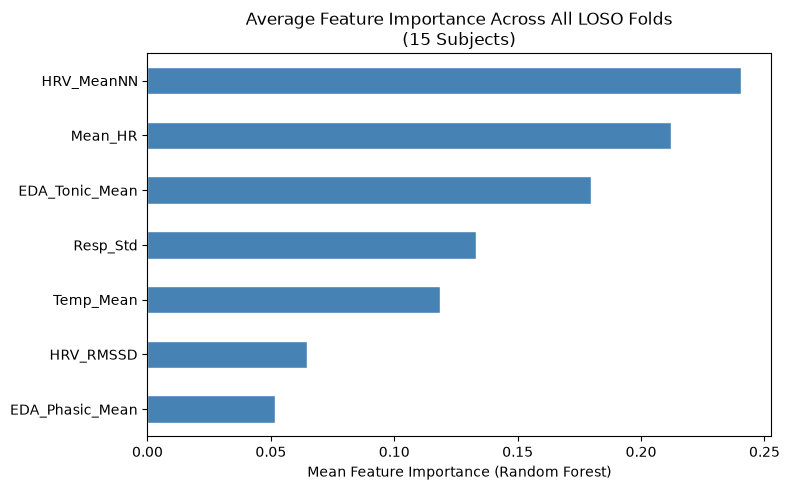

In [14]:
importance_df = pd.Series(results['feature_importances']).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance_df.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Feature Importance Across All LOSO Folds\n(15 Subjects)',
             fontsize=12)
ax.set_xlabel('Mean Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('../outputs/loso_feature_importance.png', dpi=150)
plt.show()

In [ ]:
## Multi-Subject LOSO Results

### Feature Importance Findings
- HRV_MeanNN and Mean_HR dominate (~46% combined) — both reflect
  average heart rate, suggesting consistent HR elevation is the most
  generalizable stress marker across subjects
- EDA_Tonic_Mean rises to 3rd (vs 6th on S2 alone) — confirms skin
  conductance as a robust signal when sample size is adequate
- Temp_Mean drops from 1st to 5th — S2-only result was likely
  subject-specific; temperature is useful but not universally dominant
- HRV_RMSSD ranks lower than expected despite theoretical importance,
  reflecting high inter-individual variability in resting HRV baselines

### Key Takeaway
Multi-subject LOSO results are more reliable than single-subject findings.
Feature rankings shifted substantially with 15 subjects, underscoring
the importance of cross-subject validation in biosignal research.

In [15]:
# Direct comparison: S2 within-subject vs LOSO cross-subject
comparison = pd.DataFrame({
    'Evaluation': ['Within-Subject (S2 only)', 'LOSO Cross-Subject (15 subjects)'],
    'Accuracy':   [0.933, 0.878],
    'F1 Score':   [0.920, 0.758],
    'Note':       ['Optimistic — same subject train/test',
                   'Realistic — unseen subject evaluation']
})

print(comparison.to_string(index=False))

                      Evaluation  Accuracy  F1 Score                                  Note
        Within-Subject (S2 only)     0.933     0.920  Optimistic — same subject train/test
LOSO Cross-Subject (15 subjects)     0.878     0.758 Realistic — unseen subject evaluation


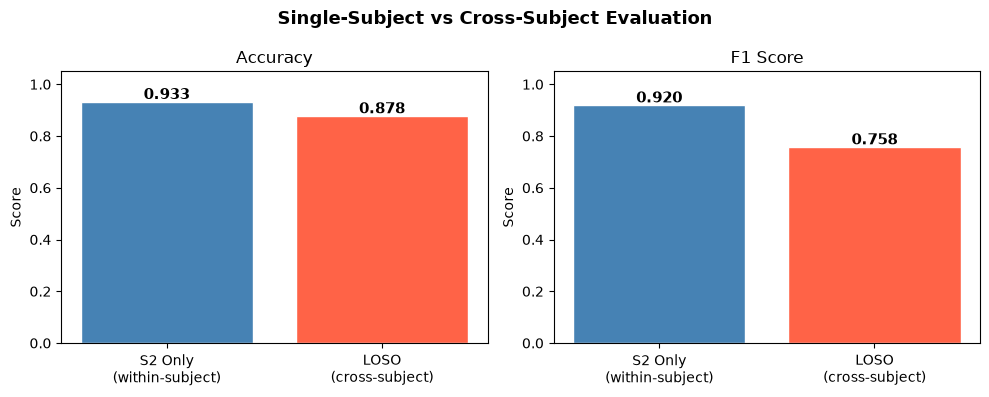

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

metrics    = ['Accuracy', 'F1 Score']
s2_vals    = [0.933, 0.920]
loso_vals  = [0.878, 0.758]

for i, (metric, s2, loso) in enumerate(zip(metrics, s2_vals, loso_vals)):
    axes[i].bar(['S2 Only\n(within-subject)', 'LOSO\n(cross-subject)'],
                [s2, loso],
                color=['steelblue', 'tomato'], edgecolor='white')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_ylabel('Score')
    for bar, val in zip(axes[i].patches, [s2, loso]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Single-Subject vs Cross-Subject Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/evaluation_comparison.png', dpi=150)
plt.show()

## From Single-Subject to Population-Level Analysis

Notebooks 03–05 demonstrated a complete stress detection pipeline on
Subject S2, achieving 0.933 accuracy and clear SHAP explanations.

**However, this evaluation has a fundamental limitation:**
the model was trained and tested on the same subject. It may have
learned S2-specific physiological patterns rather than generalizable
stress signatures.

This notebook addresses that limitation by:
1. Processing all 15 available WESAD subjects
2. Evaluating with Leave-One-Subject-Out (LOSO) cross-validation —
   each subject is tested on a model that has never seen their data
3. Comparing results to the S2 baseline to quantify the generalization gap

**Key finding preview:** S2 drops from 0.933 (within-subject) to 0.62
(cross-subject) — the largest drop of any subject. This validates the
need for multi-subject evaluation in biosignal research.